In [2]:
import requests
import os
from pathlib import Path

# Identify the books by their URL's
books = {
    "Legend_of_Sleepy_Hollow.txt": "https://www.gutenberg.org/cache/epub/41/pg41.txt",
    "Call_of_the_Wild.txt": "https://www.gutenberg.org/cache/epub/215/pg215.txt",
    "Peter_Rabbit.txt": "https://www.gutenberg.org/cache/epub/14838/pg14838.txt"
}

# Assign books names to aliases for ease of use
LoSH = "Legend_of_Sleepy_Hollow.txt"
CotW = "Call_of_the_Wild.txt"
PR = "Peter_Rabbit.txt"

# Designate directory to store books
books_dir = Path.home() / "Onedrive" / "Desktop" / "260_midterm_books"

# Download and save each book
for filename, url in books.items():
    file_path = books_dir / filename
    response = requests.get(url)
    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(response.text)



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\agan2\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\agan2\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\agan2\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\agan2\AppData\Roaming\nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!




Book Title                     | Noun         | Verb         | Adj          | Avg Len 


Legend_of_Sleepy_Hollow.txt    | project      | was          | old          | 6.32    
Call_of_the_Wild.txt           | buck         | was          | other        | 5.79    
Peter_Rabbit.txt               | project      | was          | electronic   | 6.62    




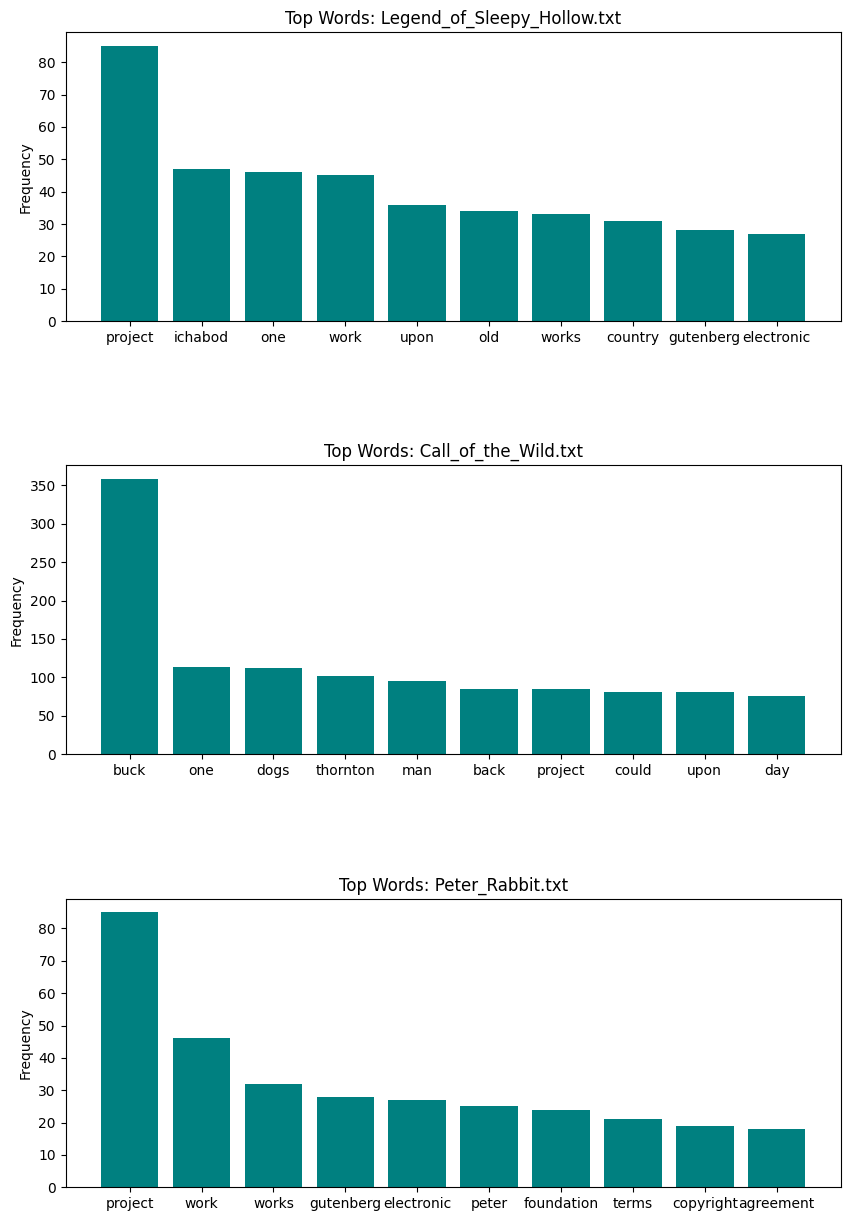

In [6]:

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from collections import Counter
import matplotlib.pyplot as plt

# Ensuring dependencies are accessible
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('universal_tagset')

def clean_and_process(url):

    # Fetch the book text
    response = requests.get(url)
    raw_text = response.text
    
    # Identify the start and end of the actual book content
    lines = raw_text.splitlines()
    start_index = 0
    end_index = len(lines)

    for i, line in enumerate(lines):
        if "START OF THE PROJECT GUTENBERG" in line:
            start_index = i + 1
        if "END OF THE PROJECT GUTENBERG" in line:
            end_index = i
            break
    
    # Use a list slice to get desired content
    book_lines = lines[start_index:end_index]

    # Remove Illustration lines and join the text
    filtered_lines = [line for line in lines[start_index:] if "[Illustration]" not in line]
    clean_text = " ".join(filtered_lines)
    
    # Tokenize alphabetic words only
    tokens = [w for w in word_tokenize(clean_text) if w.isalpha()]
    
    # POS Tagging most common Noun, Verb, Adj
    pos_tags = nltk.pos_tag(tokens, tagset='universal')
    
    return tokens, pos_tags

results = []
stop_words = set(stopwords.words('english'))

for title, url in books.items():
    tokens, pos_tags = clean_and_process(url)
    
    # Find most common Noun, Verb, Adj
    nouns = [word.lower() for word, pos in pos_tags if pos == 'NOUN']
    verbs = [word.lower() for word, pos in pos_tags if pos == 'VERB']
    adjs = [word.lower() for word, pos in pos_tags if pos == 'ADJ']
    
    most_noun = Counter(nouns).most_common(1)[0][0] if nouns else "N/A"
    most_verb = Counter(verbs).most_common(1)[0][0] if verbs else "N/A"
    most_adj = Counter(adjs).most_common(1)[0][0] if adjs else "N/A"
    
    # Avg Word Length (after removing stop words)
    filtered_tokens = [w.lower() for w in tokens if w.lower() not in stop_words]
    avg_len = sum(len(w) for w in filtered_tokens) / len(filtered_tokens) if filtered_tokens else 0
    
    # Frequency Distribution
    fdist = FreqDist(filtered_tokens)
    
    results.append({
        "Title": title,
        "Noun": most_noun,
        "Verb": most_verb,
        "Adj": most_adj,
        "Avg Length": round(avg_len, 2),
        "FDist": fdist
    })

# Fdist results for each book
print("\n")
header = f"{'Book Title':<30} | {'Noun':<12} | {'Verb':<12} | {'Adj':<12} | {'Avg Len':<8}"
print(header)
print("\n")
for res in results:
    print(f"{res['Title']:<30} | {res['Noun']:<12} | {res['Verb']:<12} | {res['Adj']:<12} | {res['Avg Length']:<8}")
print("\n")

# Compare Fdists by plotting the top 10 most common words for each book
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
plt.subplots_adjust(hspace=0.5)

for i, res in enumerate(results):
    # Get top 10 most common words
    most_common = res['FDist'].most_common(10)
    words, counts = zip(*most_common)
    
    axes[i].bar(words, counts, color='teal')
    axes[i].set_title(f"Top Words: {res['Title']}")
    axes[i].set_ylabel("Frequency")

plt.show()